# 01 — Pipeline de carregamento (dados mockados)

Objetivo: validar que o pipeline de carregamento de imagens funciona corretamente, usando os dados sinteticos gerados por `scripts/gerar_mock.py`.

Este notebook NAO aprende nada sobre croche real -- serve apenas para testar o codigo. Quando as fotos reais chegarem, este mesmo codigo sera
reaproveitado sem alteracoes.

Imports:

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Reprodutibilidade: mesmo comportamento a cada execucao do notebook.
torch.manual_seed(42)

Transforms (resize + normalização):

In [2]:
# Transform aplicado a TODA imagem que entra no pipeline.
#
# IMPORTANTE: essa normalizacao deixa os valores de pixel fora da
# faixa 0-1 (podem ficar negativos). Isso e esperado e correto para
# o treino -- mas significa que NAO da pra visualizar a imagem
# diretamente depois desse transform (ver funcao de desnormalizacao
# mais abaixo, usada so para fins de exibicao).
#

MEAN_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_IMAGENET, std=STD_IMAGENET),
])

# Resize(224, 224): padroniza o tamanho de entrada para o formato
# esperado por arquiteturas de transfer learning (ResNet, etc.) --
# decisao ja alinhada com a Fase 2 do roadmap principal.
#
# ToTensor(): converte a imagem (formato PIL/numpy, valores 0-255,
# ordem de eixos Altura x Largura x Canais) para um tensor PyTorch
# (valores 0.0-1.0, ordem de eixos Canais x Altura x Largura).
#
# Normalize(mean, std): re-escala os valores de pixel usando a media
# e desvio padrao do ImageNet. Isso e o padrao esperado por modelos
# pre-treinados nesse dataset -- sem essa normalizacao, um modelo de
# transfer learning teria desempenho pior, pois receberia os pixels
# em uma escala diferente da que aprendeu originalmente.
#

ImageFolder + DataLoader

In [3]:
# ImageFolder: forma padrao do PyTorch de carregar imagens quando elas
# ja estao organizadas em pasta_raiz/nome_da_classe/imagem.jpg -- que e
# exatamente a estrutura que temos em dataset/correto e dataset/erro.
#
# O ImageFolder detecta as classes automaticamente a partir dos nomes
# das subpastas (ordem alfabetica), e aplica o `transform` em cada
# imagem no momento em que ela e carregada (nao carrega tudo em memoria
# de uma vez -- carregamento e "preguicoso"/lazy, sob demanda).

caminho_dataset = "../dataset"
dataset_mockado = datasets.ImageFolder(root=caminho_dataset, transform=transform)

# DataLoader: envolve o dataset e cuida de agrupar em lotes (batches),
# embaralhar a ordem (shuffle) e paralelizar o carregamento -- e a
# peca que o loop de treino (item 4 do checklist) vai efetivamente
# consumir, chamando "for imagens, labels in dataloader: ...".
#
# batch_size=8: numero de imagens processadas juntas a cada passo do
# treino. Valor pequeno, adequado ao volume atual do dataset (100
# imagens = ~12-13 batches por epoca). Pode ser ajustado depois sem
# quebrar nada -- e so um parametro.
#
# shuffle=True: embaralha a ordem das imagens a cada epoca de treino,
# evitando que o modelo aprenda algum padrao espurio relacionado a
# ORDEM dos arquivos (ex: todas as "corretas" vindo antes das "erro").

dataloader_mockado = DataLoader(dataset_mockado, batch_size=8, shuffle=True)

 Testes de sanidade (item 1 do checklist)

In [4]:
# Teste 1: confirma que o dataset foi carregado com o volume esperado.

print(f"Total de imagens carregadas: {len(dataset_mockado)}")
print(f"Classes detectadas: {dataset_mockado.classes}")
print(f"Mapeamento classe -> indice: {dataset_mockado.class_to_idx}")

# Teste 2: confirma que o DataLoader consegue montar pelo menos um
# lote (batch) sem erro -- isso ja testa, na pratica, que TODAS as
# imagens abrem corretamente (uma imagem corrompida ou formato
# invalido geraria erro aqui).

imagens, labels = next(iter(dataloader_mockado))
print(f"Formato do lote de imagens: {imagens.shape}")  # esperado: [8, 3, 224, 224]
print(f"Formato do lote de labels: {labels.shape}")    # esperado: [8]
print(f"Labels do primeiro lote: {labels}")

Total de imagens carregadas: 100
Classes detectadas: ['correto', 'erro']
Mapeamento classe -> indice: {'correto': 0, 'erro': 1}
Formato do lote de imagens: torch.Size([8, 3, 224, 224])
Formato do lote de labels: torch.Size([8])
Labels do primeiro lote: tensor([1, 0, 0, 1, 0, 0, 0, 0])


Teste de carregamento completo (percorrer tudo)

In [5]:
# Teste 3: percorre todo o dataset (todos os batches), nao so o
# primeiro. Isso garante que nenhuma imagem no meio ou no fim da
# pasta esta corrompida ou causa erro -- e o teste mais completo do
# item 1 do checklist ("testar com qualquer imagem, garantir que nao
# quebra").
total_imagens_verificadas = 0
for imagens, labels in dataloader_mockado:
    total_imagens_verificadas += imagens.shape[0]

print(f"Total de imagens percorridas sem erro: {total_imagens_verificadas}")
assert total_imagens_verificadas == len(dataset_mockado), "Numero de imagens percorridas nao bate com o total do dataset!"
print("OK: pipeline de carregamento validado.")

Total de imagens percorridas sem erro: 100
OK: pipeline de carregamento validado.


Função de desnormalização (para visualização)

In [6]:
def mostrar_imagem_normalizada(tensor_imagem, titulo=None):
    """Desnormaliza e exibe um tensor de imagem do PyTorch.

    Necessario porque o transform aplicado (Normalize com media/desvio
    do ImageNet) deixa os valores de pixel fora da faixa 0-1, o que faz
    o matplotlib exibir cores completamente distorcidas se plotado
    direto. Esta funcao reverte a normalizacao apenas para fins de
    exibicao -- nao afeta o tensor usado no treino.
    """
    # PyTorch usa [Canais, Altura, Largura] -> Matplotlib usa [Altura, Largura, Canais]
    imagem = tensor_imagem.numpy().transpose((1, 2, 0))

    mean = np.array(MEAN_IMAGENET)
    std = np.array(STD_IMAGENET)

    # Matematica inversa da normalizacao: pixel_original = pixel_normalizado * std + mean
    imagem = std * imagem + mean

    # Corrige pequenas imprecisoes de ponto flutuante que poderiam
    # deixar valores levemente fora de 0-1.
    imagem = np.clip(imagem, 0, 1)

    plt.imshow(imagem)
    if titulo:
        plt.title(titulo)
    plt.axis('off')

 Visualização de 8 amostras (4 de cada classe)

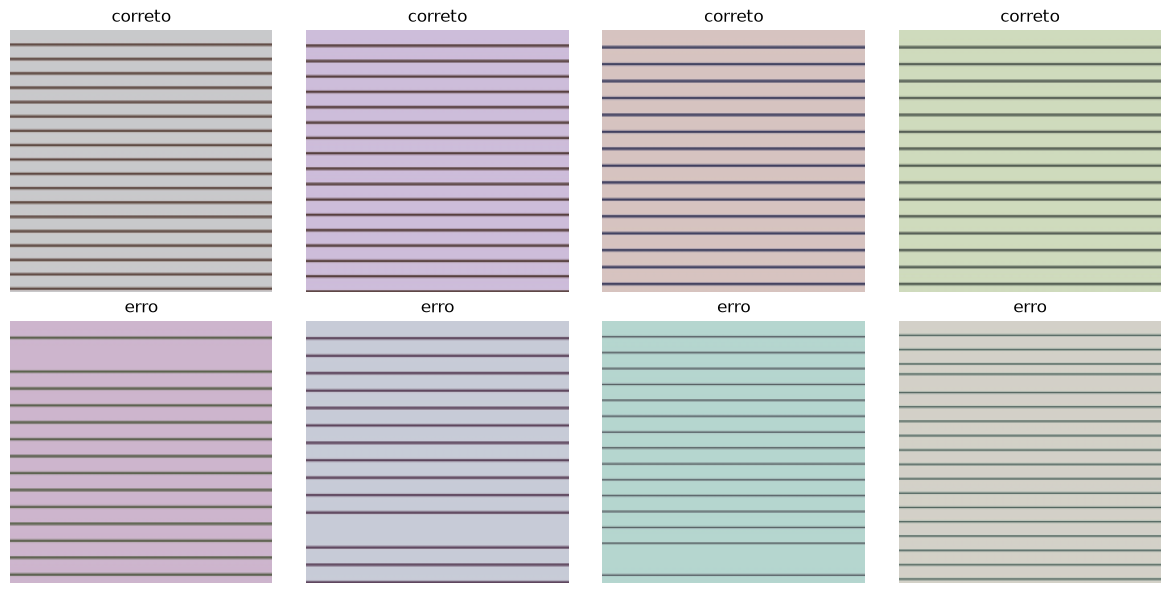

In [7]:
# Pega um lote e organiza para garantir 4 exemplos de cada classe,
# em vez de confiar no shuffle aleatorio (que poderia trazer um lote
# desbalanceado por acaso).
imagens_correto, imagens_erro = [], []

for imagens, labels in dataloader_mockado:
    for img, label in zip(imagens, labels):
        classe = dataset_mockado.classes[label]
        if classe == "correto" and len(imagens_correto) < 4:
            imagens_correto.append((img, classe))
        elif classe == "erro" and len(imagens_erro) < 4:
            imagens_erro.append((img, classe))
    if len(imagens_correto) >= 4 and len(imagens_erro) >= 4:
        break

amostras = imagens_correto + imagens_erro

plt.figure(figsize=(12, 6))
for i, (img, classe) in enumerate(amostras):
    plt.subplot(2, 4, i + 1)
    mostrar_imagem_normalizada(img, titulo=classe)

plt.tight_layout()
plt.show()